<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 10 - Recommendation Systems using Matrix Factorization
(SVD & NMF)


SCENARIO 1 – MATRIX FACTORIZATION USING SVD

Problem Statement

    Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.

Dataset (Kaggle – Public)

    MovieLens Dataset

Dataset Link: https://www.kaggle.com/datasets/grouplens/movielens-100k
(You can pick any dataset if required)

Target Variable: Predicted ratings for unseen movies

Input Feature:

    • User ID
    • Movie ID
    • Ratings

IN-LAB TASKS

    1.	Import required Python libraries (NumPy, Pandas, Scikit-learn, Surprise, etc.)
    2.	Load the MovieLens dataset
    3.	Perform data preprocessing
    4.	Create User-Item Interaction Matrix
    5.	Normalize the matrix (optional – mean centering)
    6.	Apply SVD decomposition
    7.	Reduce dimensions (select k latent factors)
    8.	Reconstruct the matrix
    9.	Predict missing ratings
    10.	Generate Top-N recommendations

Evaluation Metrics

    • RMSE (Root Mean Square Error)
    • MAE (Mean Absolute Error)

Analysis Tasks

    • Analyze effect of number of latent factors (k)
    • Compare predicted vs actual ratings
    • Observe how dimensionality reduction improves performance
    • Study overfitting vs underfitting


Visualization

    • Heatmap of original vs reconstructed matrix
    • Error vs number of latent factors
    • Top recommended movies



Preethi R 24BAD091

Original Ratings Shape: (382523, 4)
After Sampling: (30000, 3)
Unique Users: 2506
Unique Movies: 5436
Matrix Shape: (2506, 5436)

Top Recommendations for User 26:
                                title
148                  Apollo 13 (1995)
293               Pulp Fiction (1994)
315  Shawshank Redemption, The (1994)
352               Forrest Gump (1994)
476              Jurassic Park (1993)

RMSE: 40.09686340625743
MAE: 16.23104762529208


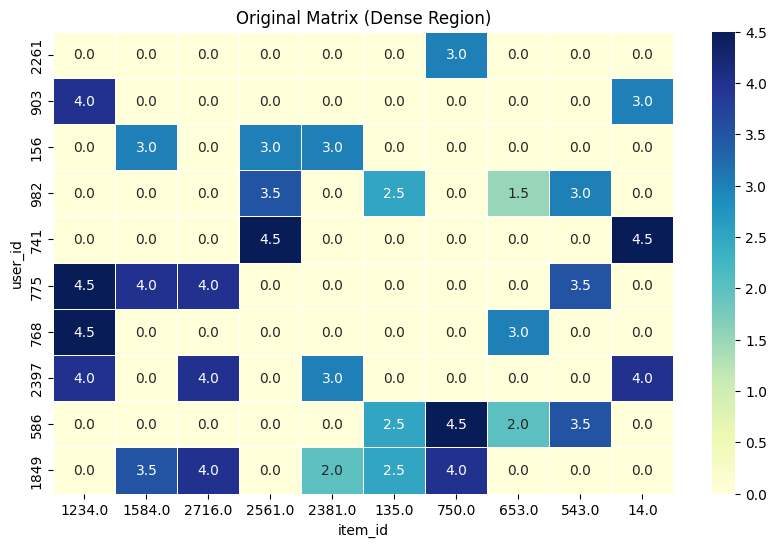

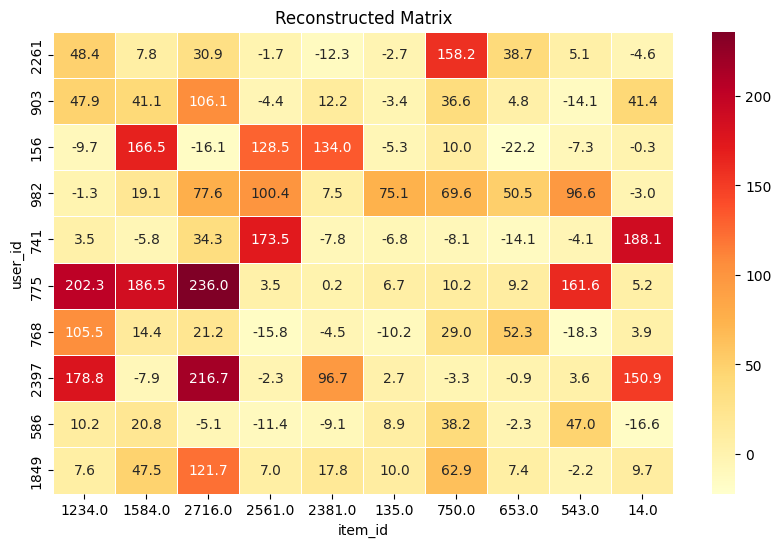

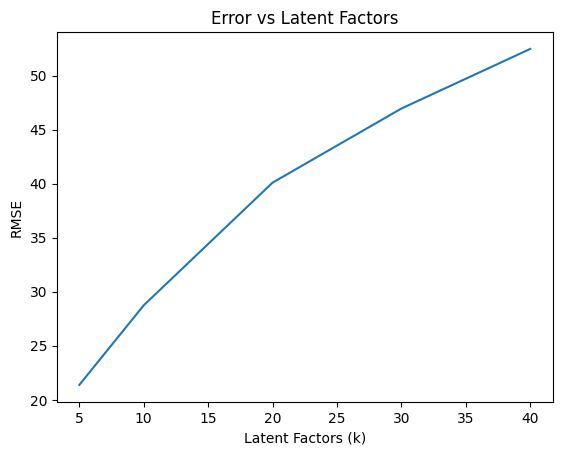


Top Recommendations for User 706:
                                                  title
0                                      Toy Story (1995)
108                                   Braveheart (1995)
148                                    Apollo 13 (1995)
352                                 Forrest Gump (1994)
1184  Star Wars: Episode VI - Return of the Jedi (1983)


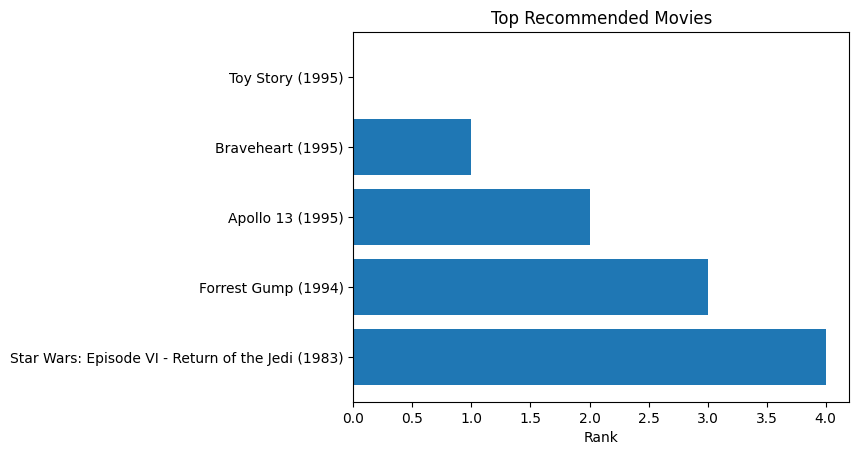

In [1]:
print("Preethi R 24BAD091\n")

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD

# 2. Load Dataset
ratings = pd.read_csv("rating.csv")
movies = pd.read_csv("movie.csv")

print("Original Ratings Shape:", ratings.shape)

# 3. Preprocessing
ratings.columns = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = ratings.drop('timestamp', axis=1)

# Fix movie dataset
if 'movieId' in movies.columns:
    movies = movies[['movieId', 'title']]
    movies.columns = ['item_id', 'title']
else:
    movies.columns = ['item_id', 'title']

# 4. Reduce dataset size (Memory Fix)
ratings = ratings.sample(n=30000, random_state=42)

print("After Sampling:", ratings.shape)
print("Unique Users:", ratings['user_id'].nunique())
print("Unique Movies:", ratings['item_id'].nunique())

# 5. Create User-Item Matrix
user_item_matrix = ratings.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating',
    fill_value=0
)

print("Matrix Shape:", user_item_matrix.shape)

# Safety check
if user_item_matrix.shape[0] == 0 or user_item_matrix.shape[1] == 0:
    raise ValueError("Matrix is empty. Increase sample size.")

# 6. Normalize
mean_user_rating = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(mean_user_rating, axis=0)

# 7. Apply SVD
k = min(20, matrix_norm.shape[0]-1, matrix_norm.shape[1]-1)

if k < 1:
    raise ValueError("k is too small.")

svd = TruncatedSVD(n_components=k, random_state=42)
U = svd.fit_transform(matrix_norm)
Sigma = svd.singular_values_
VT = svd.components_

# 8. Reconstruct Matrix
reconstructed = np.dot(U, np.dot(np.diag(Sigma), VT))
reconstructed += mean_user_rating.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

# 9. Predictions
predictions = reconstructed_df

# 10. Recommendations
def recommend_movies(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    sorted_predictions = predictions.loc[user_id].sort_values(ascending=False)

    recommendations = sorted_predictions[user_ratings == 0].head(n)

    recommended_movies = movies[movies['item_id'].isin(recommendations.index)]
    return recommended_movies[['title']]

# Pick valid user
sample_user = np.random.choice(user_item_matrix.index)

print(f"\nTop Recommendations for User {sample_user}:")
print(recommend_movies(sample_user))

# 11. Evaluation (ONLY NON-ZERO VALUES)
mask = user_item_matrix.values > 0

rmse = np.sqrt(mean_squared_error(
    user_item_matrix.values[mask],
    reconstructed_df.values[mask]
))

mae = mean_absolute_error(
    user_item_matrix.values[mask],
    reconstructed_df.values[mask]
)

print("\nRMSE:", rmse)
print("MAE:", mae)

# 12. Visualization (FINAL FIX)
# Find users with highest activity
user_activity = user_item_matrix.astype(bool).sum(axis=1)

# Pick top active users
top_users = user_activity.sort_values(ascending=False).head(10).index

# Now find movies rated by these users
subset = user_item_matrix.loc[top_users]

# Select movies that actually have ratings in this subset
movie_activity = subset.astype(bool).sum(axis=0)
top_items = movie_activity.sort_values(ascending=False).head(10).index

# Final dense matrix
original_dense = user_item_matrix.loc[top_users, top_items]
reconstructed_dense = reconstructed_df.loc[top_users, top_items]

# Plot Original
plt.figure(figsize=(10,6))
sns.heatmap(
    original_dense,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Original Matrix (Dense Region)")
plt.show()

# Plot Reconstructed
plt.figure(figsize=(10,6))
sns.heatmap(
    reconstructed_dense,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Reconstructed Matrix")
plt.show()

# 13. Error vs Latent Factors
errors = []
k_values = [5, 10, 20, 30, 40]

# Use only non-zero values for accuracy
mask = user_item_matrix.values > 0

for k_val in k_values:
    k_val = min(k_val, matrix_norm.shape[0]-1, matrix_norm.shape[1]-1)

    if k_val < 1:
        continue

    svd = TruncatedSVD(n_components=k_val, random_state=42)
    U = svd.fit_transform(matrix_norm)
    Sigma = svd.singular_values_
    VT = svd.components_

    recon = np.dot(U, np.dot(np.diag(Sigma), VT))
    recon += mean_user_rating.values.reshape(-1, 1)

    rmse_val = np.sqrt(mean_squared_error(
        user_item_matrix.values[mask],
        recon[mask]
    ))

    errors.append(rmse_val)

plt.plot(k_values[:len(errors)], errors)
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

# 14.Top Recommended Movies
# Pick a valid user
sample_user = np.random.choice(user_item_matrix.index)

print(f"\nTop Recommendations for User {sample_user}:")

recommended_movies = recommend_movies(sample_user)

print(recommended_movies)

# Optional: show as bar chart
if not isinstance(recommended_movies, str):
    plt.figure()
    plt.barh(recommended_movies['title'], range(len(recommended_movies)))
    plt.xlabel("Rank")
    plt.title("Top Recommended Movies")
    plt.gca().invert_yaxis()
    plt.show()

SCENARIO 2 – MATRIX FACTORIZATION USING NMF

Problem Statement

    Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.

Dataset (Same / Alternative Dataset)

    Same MovieLens Dataset (or any rating dataset)

Target Variable: Predicted ratings / Recommendations

Input Features

    • User ID
    • Movie ID
    • Ratings

IN-LAB TASKS

    1.	Load dataset
    2.	Create User-Item matrix
    3.	Handle missing values (fill with 0 or mean)
    4.	Apply NMF model
    5.	Factorize into:
    a.	User-feature matrix
    b.	Item-feature matrix
    6.	Reconstruct the rating matrix
    7.	Predict missing values
    8.	Generate Top-N recommendations

Evaluation Metrics

    • RMSE
    • Precision@K
    • Recall@K

Analysis Tasks

    • Compare SVD vs NMF performance
    • Observe interpretability of NMF factors
    • Analyze sparsity handling
    • Compare recommendation diversity

Visualization

    • Latent feature visualization
    • Reconstruction comparison
    • Recommendation ranking chart


Preethi R 24BAD091

Original Ratings Shape: (445466, 4)
Users: 2866
Movies: 5432


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(



Top Recommendations for User 2346:
                                                 title
102                               Happy Gilmore (1996)
373                                       Speed (1994)
476                               Jurassic Park (1993)
1175                                     Aliens (1986)
2543  Star Wars: Episode I - The Phantom Menace (1999)

RMSE: 3.4272361146837738
Precision@5: 0.1536636427076064
Recall@5: 0.13471162833728798


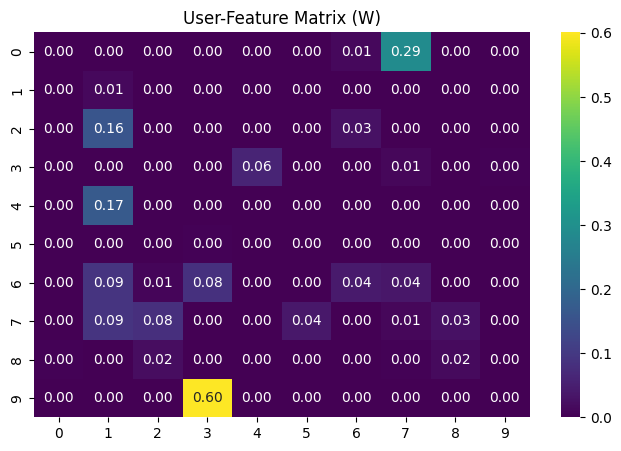

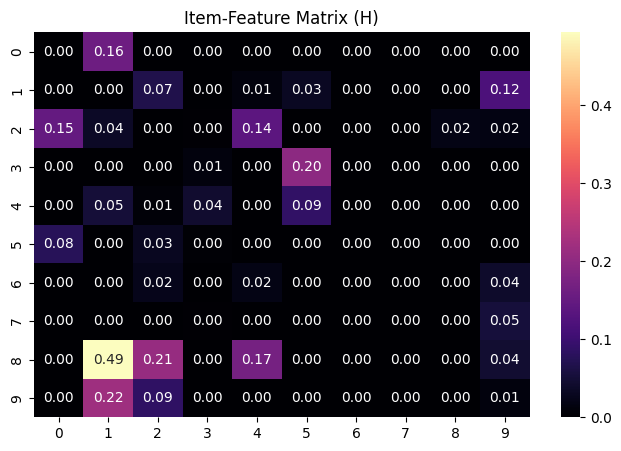

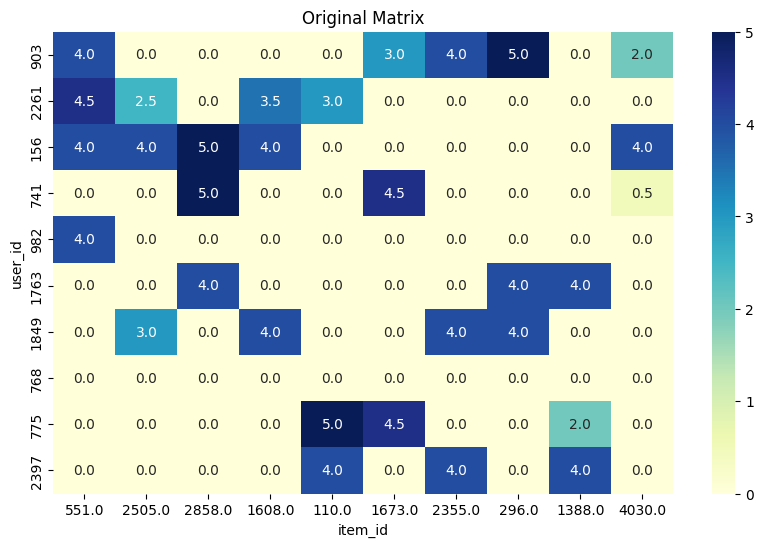

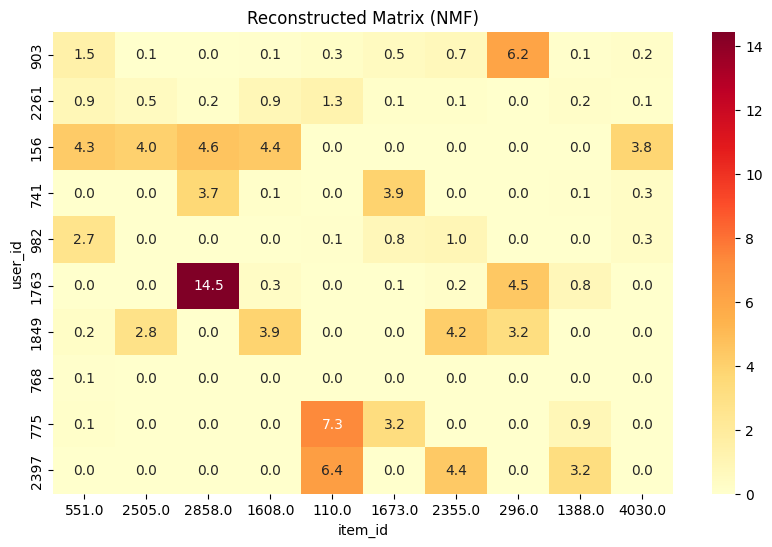

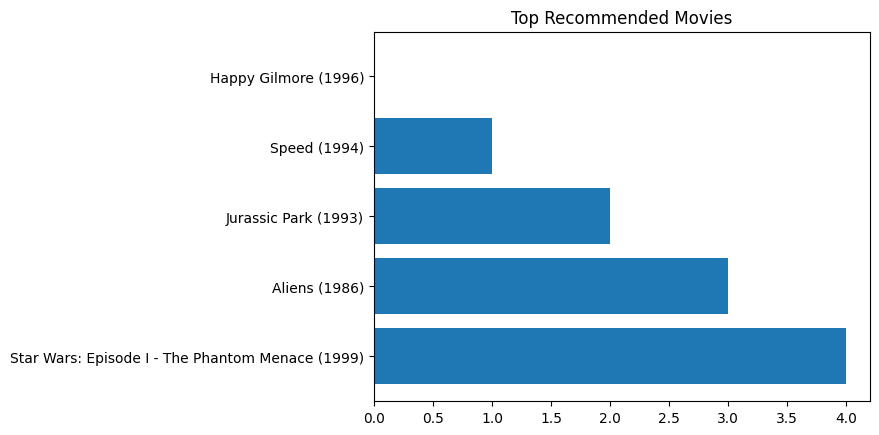

In [2]:
print("Preethi R 24BAD091\n")

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# 2. Load Dataset
ratings = pd.read_csv("rating.csv")
movies = pd.read_csv("movie.csv")

print("Original Ratings Shape:", ratings.shape)

# 3. Preprocessing
ratings.columns = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = ratings.drop('timestamp', axis=1)

# Fix movie dataset
if 'movieId' in movies.columns:
    movies = movies[['movieId', 'title']]
    movies.columns = ['item_id', 'title']
else:
    movies.columns = ['item_id', 'title']

# Reduce size (memory safe)
ratings = ratings.sample(n=30000, random_state=42)

print("Users:", ratings['user_id'].nunique())
print("Movies:", ratings['item_id'].nunique())

# 4. Create User-Item Matrix
user_item_matrix = ratings.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating',
    fill_value=0
)

# 5. Apply NMF
k = 20
nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(user_item_matrix)   # User-feature matrix
H = nmf_model.components_                       # Item-feature matrix

# 6. Reconstruct Matrix
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

# 7. Predict Missing Values
predictions = reconstructed_df

# 8. Top-N Recommendations
def recommend_movies(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    preds = predictions.loc[user_id]

    recommendations = preds[user_ratings == 0].sort_values(ascending=False).head(n)

    recommended_movies = movies[movies['item_id'].isin(recommendations.index)]
    return recommended_movies[['title']]

# Select valid user
sample_user = np.random.choice(user_item_matrix.index)

print(f"\nTop Recommendations for User {sample_user}:")
print(recommend_movies(sample_user))

# Evaluation

# RMSE (only non-zero values)
mask = user_item_matrix.values > 0

rmse = np.sqrt(mean_squared_error(
    user_item_matrix.values[mask],
    reconstructed_df.values[mask]
))

print("\nRMSE:", rmse)

# Precision@K & Recall@K

def precision_recall_at_k(k=5):
    precisions = []
    recalls = []

    for user in user_item_matrix.index:
        actual_items = set(user_item_matrix.loc[user][user_item_matrix.loc[user] > 0].index)
        predicted_items = set(
            predictions.loc[user].sort_values(ascending=False).head(k).index
        )

        if len(actual_items) == 0:
            continue

        relevant = actual_items & predicted_items

        precision = len(relevant) / k
        recall = len(relevant) / len(actual_items)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(5)

print("Precision@5:", precision)
print("Recall@5:", recall)

# Visualization

# 1. Latent Feature Visualization
plt.figure(figsize=(8,5))
sns.heatmap(W[:10, :10], cmap="viridis", annot=True, fmt=".2f")
plt.title("User-Feature Matrix (W)")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(H[:10, :10], cmap="magma", annot=True, fmt=".2f")
plt.title("Item-Feature Matrix (H)")
plt.show()

# 2. Reconstruction Comparison (Dense Region)

user_activity = user_item_matrix.astype(bool).sum(axis=1)
top_users = user_activity.sort_values(ascending=False).head(10).index

subset = user_item_matrix.loc[top_users]
movie_activity = subset.astype(bool).sum(axis=0)
top_items = movie_activity.sort_values(ascending=False).head(10).index

original_dense = user_item_matrix.loc[top_users, top_items]
reconstructed_dense = reconstructed_df.loc[top_users, top_items]

plt.figure(figsize=(10,6))
sns.heatmap(original_dense, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(reconstructed_dense, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Reconstructed Matrix (NMF)")
plt.show()

# 3. Recommendation Ranking Chart

recommended = recommend_movies(sample_user)

if not isinstance(recommended, str):
    plt.figure()
    plt.barh(recommended['title'], range(len(recommended)))
    plt.title("Top Recommended Movies")
    plt.gca().invert_yaxis()
    plt.show()